In [1]:
# --- 1. imports -------------------------------------------------------------
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "eos").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from eos.dd2.parameters import Parameters as DD2Parameters
from eos.dd2.species import SpeciesFlags as DD2Flags
from eos.dd2.api import eos_table as dd2_eos_table
from eos.dd2.table import rows_from_result as dd2_rows_from_result

from eos.njl.parameters import Parameters as NJLParameters
from eos.njl.species import SpeciesFlags as NJLFlags
from eos.njl.api import eos_table as njl_eos_table
from eos.njl.table import rows_from_result as njl_rows_from_result

from eos.mixed.adapters import dd2_phase, njl_phase
from eos.mixed.species import SpeciesFlags as MixedFlags
from eos.mixed.api import eos_table as mixed_eos_table, hybrid_table
from eos.mixed.table import make_charge_spec
from eos.mixed.hybrid import mass_radius_mixed

from eos.general.figure_style import (LABELS, OKAB_CAT, PARTICLE_STYLES,
                                      log_decades, particle_style,
                                      save_figure, set_paper_style)

set_paper_style()

FIG_DIR = ROOT / "output" / "hybrid_stars"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# --- 2. the hybrid EoS: DD2 + NJL, one build per eta ------------------------
# Everything this notebook chooses is in this block. `eta` is the mixed-phase
# knob (0 Gibbs .. 1 Maxwell) and is a scalar per call, not an axis, so it is
# swept by rebuilding; every other input is fixed across the sweep.

MODE = "beta_eq_neutrinoless"          # (n_B, T), charge neutral
T = 0.0                                # MeV
ETAS = (0.0, 0.5, 1.0)                 # the swept parameter
CSC = True                            # colour superconductivity in the quarks.
                                       # True enumerates the pairing patterns at
                                       # every solver call: measured here, the
                                       # sweep below goes from ~1 min to hours.
NJL_BACKEND = "fast"                   # the jitted kernel; "reference" is what
                                       # correctness is judged against
ETA_COMPOSITION = 0.0                  # which eta the Y_i panel shows

HADRONIC_SET = "DD2Y"                   # "DD2Y" for the hyperon couplings
MUONS = True                           # the muon family, in every phase
DD2_FLAGS = DD2Flags(muons=MUONS)
NJL_FLAGS = NJLFlags(csc=CSC, muons=MUONS)
MIXED_FLAGS = MixedFlags(muons=MUONS)

N_B = np.linspace(0.08, 1.60, 200)      # fm^-3
N_B_QUARK = np.linspace(0.08, 1.60, 200)  # coarser: the pure paired-quark sweep
                                       # enumerates pairing patterns per point

phases = (dd2_phase(DD2Parameters.named(HADRONIC_SET), DD2_FLAGS),
          njl_phase(NJLParameters.default(), NJL_FLAGS, backend=NJL_BACKEND))
# `mass_radius_mixed` takes the charge spec directly; the public entry points
# above take the mode and build the same thing.
spec = make_charge_spec(MODE, {}, leptons=None)

# The pure branches, once: they supply the composition OUTSIDE the coexistence
# window, where the mixed engine solves nothing (window_only=True). Their row
# keys are those of `eos.mixed.composition_row`, so the three concatenate.
t0 = time.time()
had_rows = dd2_rows_from_result(dd2_eos_table(
    DD2Parameters.named(HADRONIC_SET), MODE, DD2_FLAGS,
    {"nB": N_B, "T": np.array([T])}))
qrk_rows = njl_rows_from_result(njl_eos_table(
    NJLParameters.default(), MODE, NJL_FLAGS,
    {"nB": N_B_QUARK, "T": np.array([T])}, backend=NJL_BACKEND))
print(f"pure branches: {len(had_rows)} hadronic + {len(qrk_rows)} quark rows "
      f"({time.time() - t0:.0f} s)")

runs = {}
for eta in ETAS:
    t0 = time.time()
    # The window is located once and handed to the hybrid build, so the
    # boundary scan is not repeated for the same eta.
    rows, windows = mixed_eos_table(phases, MODE, MIXED_FLAGS,
                                    axes={"nB": N_B, "T": np.array([T])},
                                    eta=eta)
    window = windows[(float(T),)]
    result = hybrid_table(phases, MODE, MIXED_FLAGS, n_B_grid=N_B, eta=eta,
                          T=T, window=window)
    if not result.ok:
        print(f"eta = {eta}: {result.message}")
        continue
    table = result.table
    mr = mass_radius_mixed(phases, N_B, eta, spec, T=T, table=table)

    # Full-range composition: pure hadronic below the onset, the mixed rows
    # inside, pure quark above the offset.
    if table.has_transition:
        composition = ([r for r in had_rows if r["n_B"] < table.n_onset]
                       + list(rows)
                       + [r for r in qrk_rows if r["n_B"] > table.n_offset])
    else:
        composition = list(had_rows)
    composition.sort(key=lambda r: r["n_B"])

    runs[eta] = dict(table=table, mr=mr, composition=composition)
    print(f"eta = {eta:.2f}   n_onset = {table.n_onset:.3f}   "
          f"n_offset = {table.n_offset:.3f} fm^-3   "
          f"M_max = {mr['M_max']:.3f} Msun   R(1.4) = {mr['R_1p4']:.2f} km   "
          f"({time.time() - t0:.0f} s)")

pure branches: 90 hadronic + 25 quark rows (79 s)


KeyboardInterrupt: 

Saved: /Users/mircoguerrini/Desktop/Research/Python_codes/eos/output/hybrid_stars/hybrid_stars.{png, pdf}


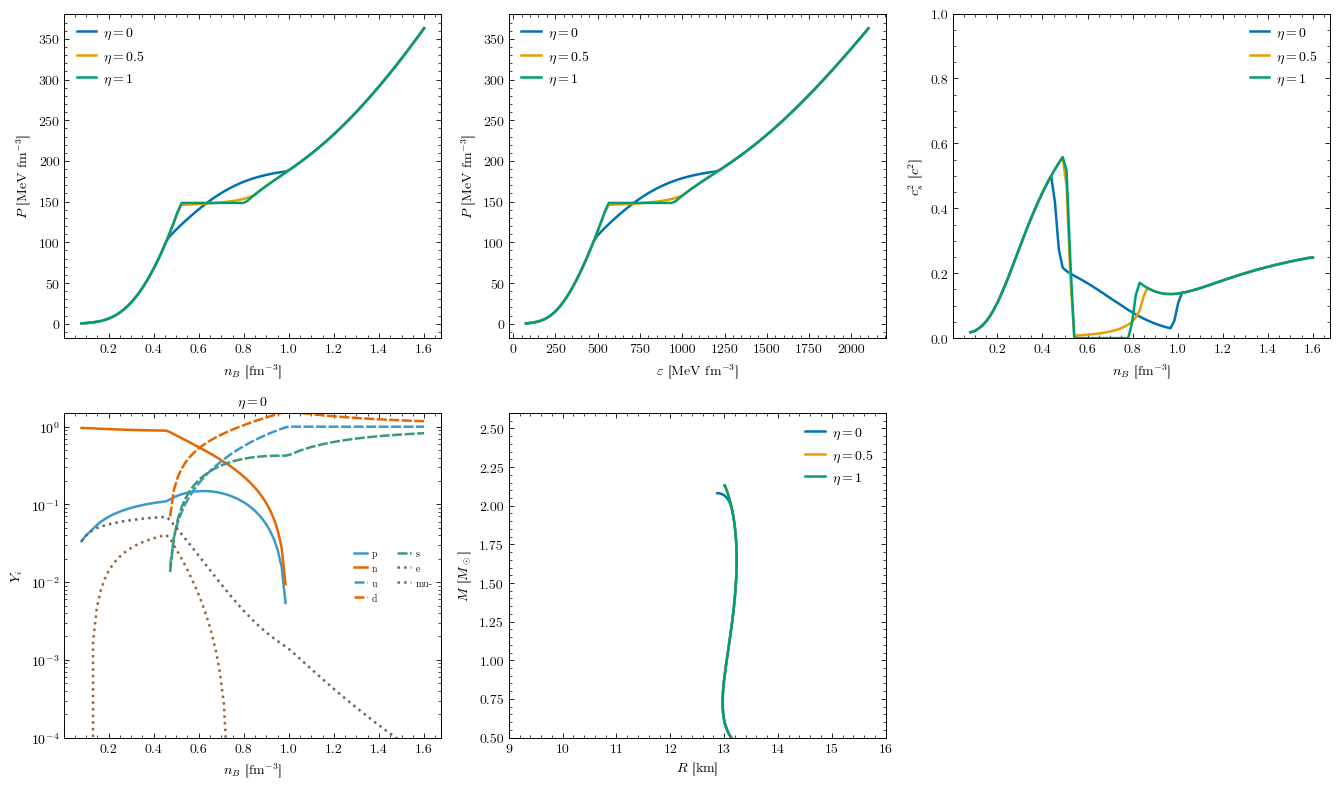

In [ ]:
# --- 3. figures -------------------------------------------------------------
COLOR = {eta: OKAB_CAT[i] for i, eta in enumerate(ETAS)}

fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.0))
ax_P_n, ax_P_e, ax_cs2, ax_Yi, ax_MR, ax_off = axes.flat
ax_off.axis("off")

for eta, run in runs.items():
    t, mr = run["table"], run["mr"]
    label = rf"$\eta = {eta:g}$"
    style = dict(color=COLOR[eta], lw=1.8, label=label)

    ax_P_n.plot(t.n_B, t.P, **style)
    ax_P_e.plot(t.eps, t.P, **style)
    # Equilibrium sound speed of the table the TOV solver integrates.
    ax_cs2.plot(t.n_B, np.gradient(t.P, t.eps), **style)
    idx = int(np.argmax(mr["results"][:, 4]))
    ax_MR.plot(mr["results"][:idx + 1, 3], mr["results"][:idx + 1, 4], **style)

ax_P_n.set_xlabel(LABELS["nB"]); ax_P_n.set_ylabel(LABELS["P"])
ax_P_e.set_xlabel(LABELS["epsilon"]); ax_P_e.set_ylabel(LABELS["P"])
ax_cs2.set_xlabel(LABELS["nB"]); ax_cs2.set_ylabel(r"$c_s^2$ [$c^2$]")
ax_cs2.set_ylim(0.0, 1.0)
ax_MR.set_xlabel(r"$R$ [km]"); ax_MR.set_ylabel(r"$M$ [$M_\odot$]")
ax_MR.set_xlim(9.0, 16.0); ax_MR.set_ylim(0.5, 2.6)
for ax in (ax_P_n, ax_P_e, ax_cs2, ax_MR):
    ax.legend(frameon=False)

# Composition at one eta: colour by particle, linestyle by multiplet.
composition = runs[ETA_COMPOSITION]["composition"]
n_B = np.array([r["n_B"] for r in composition])
present = {key[2:] for row in composition for key in row if key.startswith("Y_")}
for name in PARTICLE_STYLES:
    if name not in present:
        continue
    Y = np.array([r.get(f"Y_{name}", np.nan) for r in composition])
    if np.nanmax(Y) < 1e-4:
        continue
    colour, linestyle = particle_style(name)
    ax_Yi.plot(n_B, Y, color=colour, ls=linestyle, label=name)
ax_Yi.set_xlabel(LABELS["nB"]); ax_Yi.set_ylabel(LABELS["Y_i"])
ax_Yi.set_yscale("log"); ax_Yi.set_ylim(1e-4, 1.5)
log_decades(ax_Yi)
ax_Yi.set_title(rf"$\eta = {ETA_COMPOSITION:g}$")
ax_Yi.legend(frameon=False, ncol=2, fontsize=7)

fig.tight_layout()
save_figure(fig, str(FIG_DIR / "hybrid_stars"))
plt.show()

=== njl, beta_eq_neutrinoless, T = 0.0 MeV, eta_D = 1.45, backend = 'fast', 40 densities ===
  unpaired   40/40 solved,  40 realised as unpaired     0.08 s total,  0.002 s/point
  2SC        40/40 solved,  40 realised as 2SC          1.13 s total,  0.028 s/point
  CFL        40/40 solved,  31 realised as CFL         14.00 s total,  0.350 s/point


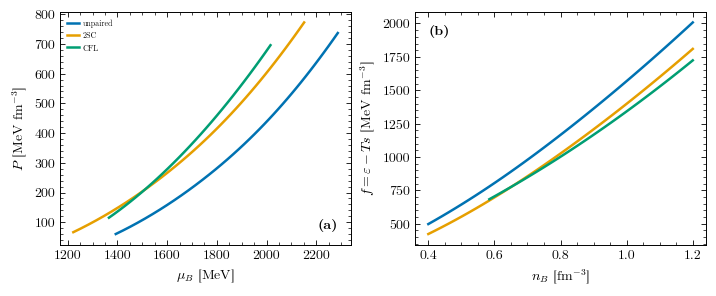

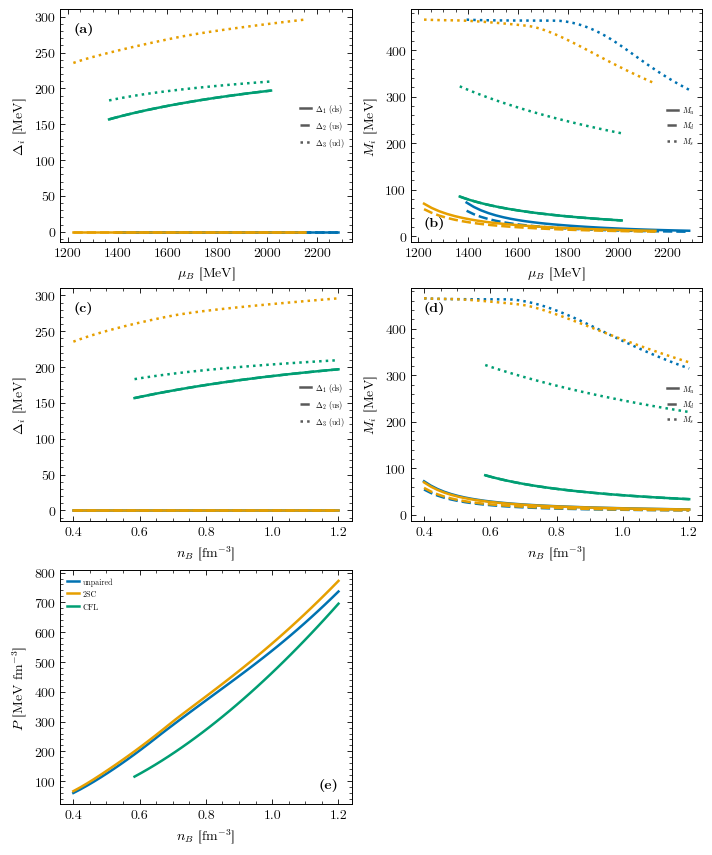